# Task 1 (Extra): Gradient Flow Through Skip Connections — Unfrozen Backbone
EE-5102/CS-6304 - Advanced Topics in Machine Learning - Programming Assignment 0

**Why this notebook exists.** Part 2 of `Task1_ResNet152_CNN_v3.ipynb` disables skip
connections in a few `Bottleneck` blocks and re-trains, but the backbone is *frozen*
there (only the classification head is trained). With the backbone frozen, no
gradient ever reaches the disabled blocks in the first place, so "does removing skip
connections hurt gradient flow?" can't really be answered from that experiment — there
is no backward signal traveling through the backbone to disrupt.

This notebook re-runs the residual-connection ablation with the **backbone fully
unfrozen**, and instruments the forward/backward pass directly (per-block gradient
norms, activation statistics, weight-update magnitudes) so the vanishing-gradient
story can be shown quantitatively rather than just inferred from a big accuracy drop.

Directory conventions match the main notebook: `DATA_DIR = "../data"` and the shared
`torch.hub` weights cache is `"../weights"`. The one difference is that checkpoints
saved *by this notebook* go to `../weights/Task1_extra/` instead of
`../weights/part1_test1/`, so they don't collide with the main notebook's checkpoints.


## 0. Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torch.autograd.functional import jvp, vjp
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy, time, random, os, gc
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
DATA_DIR = "../data"

# GPU info
print("Using device:", device)
if torch.cuda.is_available():
    print(f"Num GPUs: {torch.cuda.device_count()}")

    current_device = torch.cuda.current_device()
    print(f"Current Device Index: {current_device}")
    print(f"Device Name: {torch.cuda.get_device_name(current_device)}")

    props = torch.cuda.get_device_properties(current_device)
    print(f"Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"CUDA Capability: {props.major}.{props.minor}")
else:
    print("PyTorch is currently using the CPU.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Set the directory where PyTorch hub / torchvision downloads model weights.
# Same shared cache as Task1_ResNet152_CNN_v3.ipynb -- pretrained ResNet-152 /
# ResNet-18 weights already downloaded there will be reused here, not re-fetched.
torch.hub.set_dir(os.path.abspath("../weights"))

# Checkpoints saved BY this notebook go in their own subdirectory so they don't
# collide with the ones saved by the main Task 1 notebook (../weights/part1_test1/).
WEIGHTS_DIR = "../weights/Task1_extra/"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Mixed-precision training (autocast + GradScaler). Only actually mixed-precision on
# CUDA; falls back to full precision automatically on CPU.
USE_AMP = device.type == "cuda"
print(f"Mixed precision (AMP) enabled: {USE_AMP}")

# Global plotting style -- recycled from Task1_ResNet152_CNN_v3.ipynb so figures in
# this notebook match the main notebook / the report.
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


Using device: cuda
Num GPUs: 1
Current Device Index: 0
Device Name: Tesla T4
Total Memory: 15.64 GB
CUDA Capability: 7.5
Mixed precision (AMP) enabled: True


### Data: CIFAR-10
Recycled verbatim from `Task1_ResNet152_CNN_v3.ipynb`: ResNet-152 expects 224x224 RGB
images normalized with ImageNet statistics, and we use the same train/val/test subset
sizes so results stay comparable to the main notebook.

## 1. Model builders

`build_resnet152_full` and `NoSkipBottleneck` / `disable_skip_connections` are recycled
from the main notebook (Parts 2 and 4). Two additions specific to this notebook:

- `get_ordered_blocks` gives a stable, depth-ordered list of every `Bottleneck` block
  (`layer1.0 ... layer4.2`, 50 blocks total for ResNet-152), which every diagnostic
  below plots against as a proxy for "depth".
- `disable_n_skip_connections_spread` lets us dial the *number* of broken skip
  connections up smoothly and spread across the whole network, for the dose-response
  experiment later — as opposed to `disable_skip_connections`, which works stage by
  stage.

Note: every experiment here uses `finetune="full"` (the whole backbone unfrozen).
`finetune="head"` is kept available only as a frozen-backbone sanity check, since a
frozen backbone (as used throughout the main notebook) receives no gradient at all,
which is exactly the case we're trying to move past.

In [ ]:
from torchvision.models.resnet import Bottleneck

def build_resnet152_full(num_classes=10, pretrained=True, finetune="full"):
    """finetune: 'full' (train all layers) or 'head' (train fc only).
    Recycled from Task1_ResNet152_CNN_v3.ipynb (Part 4).
    """
    weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.resnet152(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if finetune == "head":
        for name, p in model.named_parameters():
            p.requires_grad = name.startswith("fc")
    elif finetune == "full":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(finetune)

    return model.to(device)


class NoSkipBottleneck(Bottleneck):
    """Bottleneck block with the residual (skip) addition removed.
    Recycled from Task1_ResNet152_CNN_v3.ipynb (Part 2).
    """
    def forward(self, x):
        identity = x

        out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn2(out); out = self.relu(out)
        out = self.conv3(out); out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        # out = out + identity   # <-- skip connection disabled
        out = self.relu(out)
        return out


def get_ordered_blocks(model):
    """Return (name, module) for every Bottleneck block in forward order
    (layer1.0, layer1.1, ..., layer4.2). Everything below plots against this
    ordering as a proxy for network depth.
    """
    blocks = []
    for stage_name in ["layer1", "layer2", "layer3", "layer4"]:
        stage = getattr(model, stage_name)
        for i, block in enumerate(stage):
            blocks.append((f"{stage_name}.{i}", block))
    return blocks


def disable_skip_connections(model, layer_names=("layer1",), fraction=0.5):
    """Convert a fraction of Bottleneck blocks in the given layers to
    NoSkipBottleneck. Recycled from Task1_ResNet152_CNN_v3.ipynb (Part 2).
    """
    for layer_name in layer_names:
        stage = getattr(model, layer_name)
        n_blocks = len(stage)
        n_disable = max(1, int(round(fraction * n_blocks)))
        for i in range(n_disable):
            block = stage[i]
            block.__class__ = NoSkipBottleneck
    return model


def disable_n_skip_connections_spread(model, n):
    """Disable exactly n skip connections, spread evenly across the whole
    network (via get_ordered_blocks), rather than concentrated in one stage.
    Used for the dose-response experiment (Section 6).
    """
    blocks = get_ordered_blocks(model)
    if n <= 0:
        return model
    n = min(n, len(blocks))
    idx = np.linspace(0, len(blocks) - 1, n).round().astype(int)
    idx = sorted(set(idx.tolist()))
    for i in idx:
        _, block = blocks[i]
        block.__class__ = NoSkipBottleneck
    return model


total_blocks = len(get_ordered_blocks(build_resnet152_full(pretrained=False, finetune="head")))
print(f"ResNet-152 has {total_blocks} Bottleneck blocks total (layer1..layer4).")


ResNet-152 has 50 Bottleneck blocks total (layer1..layer4).


In [ ]:
# !! only run on Colab after uploading the dataset to drive, otherwise no need locally (if dataset is downloaded already)
import os
import tarfile
from google.colab import drive

# mount Google Drive
drive.mount('/content/drive')

# extract the CIFAR-10 archive to local Colab memory (../data)
os.makedirs(DATA_DIR, exist_ok=True)

# path to dataset file on Google Drive
tar_path = "/content/drive/MyDrive/CIFAR/cifar-10-python.tar.gz"

# extract archive if not already extracted
if not os.path.exists(os.path.join(DATA_DIR, "cifar-10-batches-py")):
    print("Extracting CIFAR-10 dataset from Google Drive...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two views of the CIFAR-10 train split: one with augmentation (for training), one
# without (for validation), plus the official CIFAR-10 test split (held out).
train_set      = datasets.CIFAR10(root=DATA_DIR, train=True,  download=False, transform=train_tfms)
train_set_eval = datasets.CIFAR10(root=DATA_DIR, train=True,  download=False, transform=eval_tfms)
test_set       = datasets.CIFAR10(root=DATA_DIR, train=False, download=False, transform=eval_tfms)

# Same subset sizes as the main notebook -- this notebook is a gradient-flow
# diagnostic, not a from-scratch accuracy benchmark, so we keep it fast.
TRAIN_SUBSET = 4000
VAL_SUBSET   = 1000
TEST_SUBSET  = 2000

train_indices = np.random.choice(len(train_set), TRAIN_SUBSET, replace=False)
val_indices   = np.random.choice(len(test_set), VAL_SUBSET, replace=False)
test_indices  = np.random.choice(len(test_set), TEST_SUBSET, replace=False)

train_subset = torch.utils.data.Subset(train_set, train_indices)
val_subset   = torch.utils.data.Subset(test_set, val_indices)
test_subset  = torch.utils.data.Subset(test_set, test_indices)

BATCH_SIZE = 16
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

classes = train_set.classes
print(classes)
print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test (held-out): {len(test_subset)}")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 4000 | Val: 1000 | Test (held-out): 2000


## 2. Gradient / activation instrumentation utilities

`register_grad_hooks` attaches a full backward hook to every Bottleneck block that
records ||dL/dx_block||_2 — the L2 norm of the gradient flowing **into** that block.
This is precisely the quantity the vanishing-gradient story is about: how much
backward signal is left by the time it reaches an early block.

`register_activation_hooks` is the forward-pass counterpart: mean/std of each block's
output activations, plus the fraction of exactly-zero entries (a proxy for "dead"
post-ReLU units), used later in Section 5.

In [ ]:
def register_grad_hooks(model):
    """Full backward hooks on every Bottleneck block, recording the L2 norm of the
    gradient flowing INTO that block (i.e. d(loss)/d(block input)).

    Returns (grad_norms, handles):
      grad_norms -- dict block_name -> float, populated once .backward() has run
      handles    -- hook handles; remove with `remove_hooks`
    """
    grad_norms = {}
    handles = []

    def make_hook(name):
        def hook(module, grad_input, grad_output):
            g = grad_input[0]
            if g is not None:
                grad_norms[name] = g.detach().norm(2).item()
        return hook

    for name, block in get_ordered_blocks(model):
        h = block.register_full_backward_hook(make_hook(name))
        handles.append(h)

    return grad_norms, handles


def remove_hooks(handles):
    for h in handles:
        h.remove()


def register_activation_hooks(model):
    """Forward hooks recording simple activation statistics (mean, std, fraction of
    exactly-zero entries) at the output of every Bottleneck block.
    """
    act_stats = {}
    handles = []

    def make_hook(name):
        def hook(module, inp, out):
            with torch.no_grad():
                out_d = out.detach()
                act_stats[name] = {
                    "mean": out_d.mean().item(),
                    "std": out_d.std().item(),
                    "dead_frac": (out_d == 0).float().mean().item(),
                }
        return hook

    for name, block in get_ordered_blocks(model):
        h = block.register_forward_hook(make_hook(name))
        handles.append(h)

    return act_stats, handles


## 3. Experiment 1 — Gradient flow at initialization (single batch, skip vs. no-skip)

The cleanest version of this comparison: one forward + backward pass, pretrained
weights, **backbone fully unfrozen**, before the optimizer has taken a single step. This
isolates the architectural effect of skip connections from any confound introduced by
training dynamics (Section 4 looks at that separately).

For a sharp, unambiguous depth-decay trend, the no-skip condition here disables **all**
50 skip connections network-wide (not just 50% of layer1/layer2 as in the main
notebook's Part 2) — since we're diagnosing an architectural property, not trying to
reproduce a specific ablation from the main notebook.

In [ ]:
probe_imgs, probe_labels = next(iter(train_loader))
probe_imgs, probe_labels = probe_imgs.to(device), probe_labels.to(device)
criterion = nn.CrossEntropyLoss()


def single_batch_grad_norms(model, imgs, labels):
    model.train()
    grad_norms, handles = register_grad_hooks(model)
    model.zero_grad(set_to_none=True)
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    remove_hooks(handles)
    return grad_norms, loss.item()


# Condition A: skip connections intact, full backbone unfrozen
model_skip = build_resnet152_full(num_classes=10, pretrained=True, finetune="full")
grads_skip, loss_skip = single_batch_grad_norms(model_skip, probe_imgs, probe_labels)
block_names_full = [n for n, _ in get_ordered_blocks(model_skip)]
del model_skip

# Condition B: ALL skip connections removed, same unfrozen backbone
model_noskip = build_resnet152_full(num_classes=10, pretrained=True, finetune="full")
model_noskip = disable_skip_connections(
    model_noskip, layer_names=("layer1", "layer2", "layer3", "layer4"), fraction=1.0
)
grads_noskip, loss_noskip = single_batch_grad_norms(model_noskip, probe_imgs, probe_labels)
del model_noskip

gc.collect();
# torch.cuda.empty_cache()
if device.type == "mps":
    torch.mps.empty_cache()
elif device.type == "cuda":
    torch.cuda.empty_cache()
print(f"Loss (skip): {loss_skip:.4f} | Loss (no-skip, all disabled): {loss_noskip:.4f}")


Loss (skip): 2.2528 | Loss (no-skip, all disabled): 2.3128


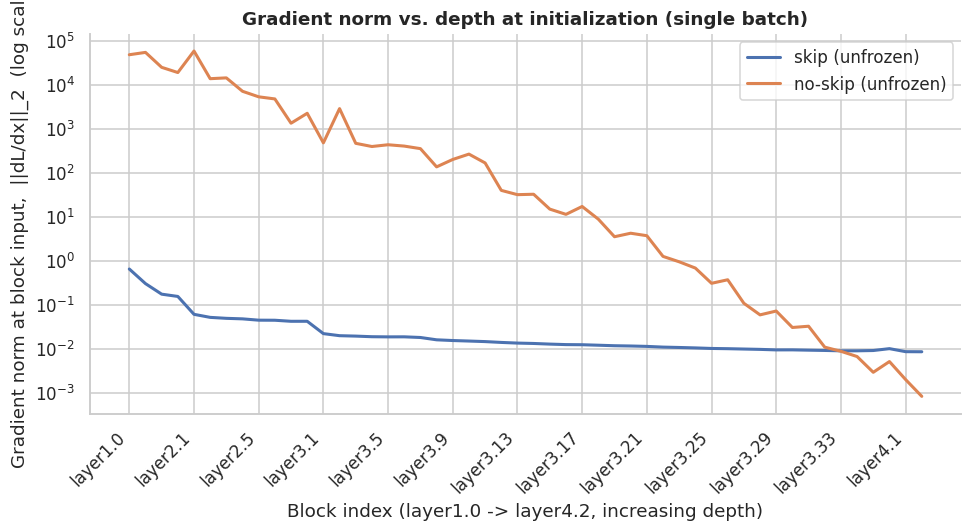

skip (unfrozen): fitted log-linear slope = -0.0560  (=> average multiplicative gradient scaling of 0.9455 per block)
no-skip (unfrozen): fitted log-linear slope = -0.3598  (=> average multiplicative gradient scaling of 0.6978 per block)


In [ ]:
def plot_grad_norms_vs_depth(grad_dicts, labels, block_names, title, fit=True):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(block_names))
    fit_stats = {}

    for grads, label in zip(grad_dicts, labels):
        y = np.array([grads.get(n, np.nan) for n in block_names])
        sns.lineplot(x=x, y=y, linewidth=2, label=label, ax=ax)

        if fit:
            mask = ~np.isnan(y) & (y > 0)
            slope, intercept = np.polyfit(x[mask], np.log(y[mask]), 1)
            fit_stats[label] = {"slope": slope, "decay_per_block": float(np.exp(slope))}

    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Block index (layer1.0 -> layer4.2, increasing depth)")
    ax.set_ylabel("Gradient norm at block input,  ||dL/dx||_2  (log scale)")
    ax.set_xticks(x[::4])
    ax.set_xticklabels([block_names[i] for i in x[::4]], rotation=45, ha="right")
    ax.legend(frameon=True)
    sns.despine()
    plt.tight_layout(); plt.show()

    for label, stats in fit_stats.items():
        print(f"{label}: fitted log-linear slope = {stats['slope']:.4f}  "
              f"(=> average multiplicative gradient scaling of {stats['decay_per_block']:.4f} per block)")
    return fit_stats


exp1_fit_stats = plot_grad_norms_vs_depth(
    [grads_skip, grads_noskip], ["skip (unfrozen)", "no-skip (unfrozen)"],
    block_names_full, "Gradient norm vs. depth at initialization (single batch)"
)
